1.   **Name:** Zumer Rafi
2.   **Student ID:** 23075913
3. **Github Link:** https://github.com/zr24aas/LLM-assignment



#Installing Libraries

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn seaborn

#Importing the Libraries

In [ ]:
import os
import random
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

#Setting Random seed and Device

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


#Mounting the Google Coolab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Loading the Dataset

In [ ]:
FILE_PATH = "/content/drive/MyDrive/IMDB Dataset.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Checking the structure of the dataset

In [ ]:
print(df.info())

print("\nColumns:")
print(df.columns.tolist())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Columns:
['review', 'sentiment']

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate rows:
418


#EDA

#This code is to set same structure of graphs

In [ ]:
CB_BLUE = "#0072B2"
CB_ORANGE = "#E69F00"
CB_GREEN = "#009E73"
CB_RED = "#D55E00"
CB_PURPLE = "#CC79A7"
CB_SKY = "#56B4E9"
CB_YELLOW = "#F0E442"
CB_BLACK = "#000000"

CB_PALETTE = [
    CB_BLUE,
    CB_ORANGE,
    CB_GREEN,
    CB_RED,
    CB_PURPLE,
    CB_SKY,
    CB_YELLOW,
    CB_BLACK
]

# Applying to Seaborn plots by default
sns.set_palette(CB_PALETTE)

# This code for Consistent figure appearance
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["figure.dpi"] = 120

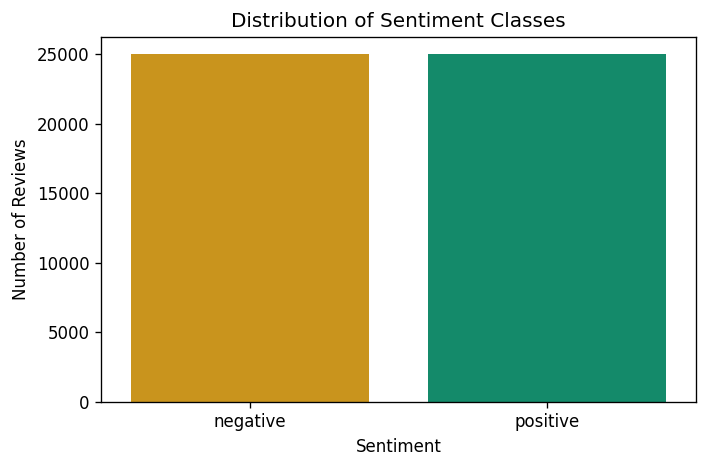

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="sentiment",
    order=["negative", "positive"],
    palette=[CB_GREEN, CB_ORANGE],
    hue="sentiment",
    legend=False
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [ ]:
class_distribution = pd.DataFrame({
    "Count": df["sentiment"].value_counts(),
    "Percentage": df["sentiment"].value_counts(normalize=True) * 100
})

display(class_distribution)

,Count,Percentage
sentiment,,
positive,25000,50.0
negative,25000,50.0


In [ ]:
df["word_count"] = df["review"].astype(str).str.split().str.len()

print(df["word_count"].describe())

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: word_count, dtype: float64


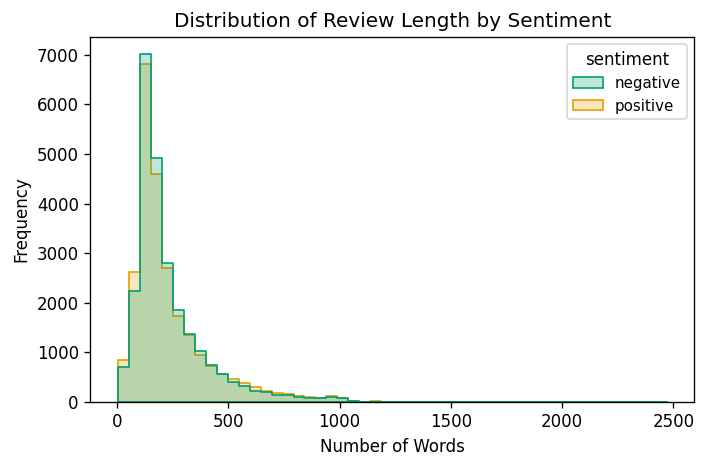

In [ ]:
plt.figure(figsize=(6, 4))

sns.histplot(
    data=df,
    x="word_count",
    hue="sentiment",
    hue_order=["negative", "positive"],
    palette={
        "negative": CB_GREEN,
        "positive": CB_ORANGE
    },
    bins=50,
    element="step"
)

plt.title("Distribution of Review Length by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
display(
    df.groupby("sentiment")["word_count"]
      .agg(["mean", "median", "std", "min", "max"])
)

,mean,median,std,min,max
sentiment,,,,,
negative,229.46456,174.0,164.947795,4,1522
positive,232.84932,172.0,177.497046,10,2470


Data Cleaning

In [ ]:
def clean_text(text):
    text = str(text)


    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)


    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)

display(df[["review", "clean_review", "sentiment"]].head())

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,A wonderful little production. The filming tec...,positive
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is...",positive


#Handling missing and dupliacate values

In [ ]:
print("Shape before cleaning:", df.shape)

df = df.dropna(subset=["clean_review", "sentiment"])
df = df[df["clean_review"].str.len() > 0]

df = df.drop_duplicates(subset=["clean_review"]).reset_index(drop=True)

print("Shape after cleaning:", df.shape)
print(df["sentiment"].value_counts())

Shape before cleaning: (50000, 4)
Shape after cleaning: (49578, 4)
sentiment
positive    24882
negative    24696
Name: count, dtype: int64


#Encoding the Labels

In [ ]:
label_map = {
    "negative": 0,
    "positive": 1
}

df["label"] = df["sentiment"].map(label_map)

print(df[["sentiment", "label"]].head())
print(df["label"].value_counts())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1
label
1    24882
0    24696
Name: count, dtype: int64


In [ ]:
#verifying the labels
assert df["label"].notna().all(), "Unexpected sentiment label found."

In [ ]:
DATASET_SIZE = 20000

df_model, _ = train_test_split(
    df,
    train_size=DATASET_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

df_model = df_model.reset_index(drop=True)

print("Dataset used for modelling:", df_model.shape)

print("\nClass distribution:")
print(df_model["sentiment"].value_counts())

print("\nPercentage:")
print(df_model["sentiment"].value_counts(normalize=True) * 100)

Dataset used for modelling: (20000, 5)

Class distribution:
sentiment
positive    10038
negative     9962
Name: count, dtype: int64

Percentage:
sentiment
positive    50.19
negative    49.81
Name: proportion, dtype: float64


#Train test Spit

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_model["clean_review"],
    df_model["label"],
    test_size=0.20,
    random_state=SEED,
    stratify=df_model["label"]
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 16000
Testing samples : 4000

Training distribution:
label
1    0.501875
0    0.498125
Name: proportion, dtype: float64

Testing distribution:
label
1    0.502
0    0.498
Name: proportion, dtype: float64


#Baseline model TF_IDF and logistic Regression

In [ ]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape :", X_test_tfidf.shape)

Training TF-IDF shape: (16000, 30000)
Testing TF-IDF shape : (4000, 30000)


In [ ]:
#traning of model
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(X_test_tfidf)

#Evaluating the baseline

In [ ]:
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted"),
        "Recall": recall_score(y_true, y_pred, average="weighted"),
        "F1-score": f1_score(y_true, y_pred, average="weighted")
    }


baseline_metrics = calculate_metrics(
    y_test,
    baseline_predictions
)

print("Baseline Results")

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        baseline_predictions,
        target_names=["Negative", "Positive"],
        digits=4
    )
)

Baseline Results
Accuracy: 0.8930
Precision: 0.8930
Recall: 0.8930
F1-score: 0.8930

Classification Report:
              precision    recall  f1-score   support

    Negative     0.8938    0.8911    0.8924      1992
    Positive     0.8923    0.8949    0.8936      2008

    accuracy                         0.8930      4000
   macro avg     0.8930    0.8930    0.8930      4000
weighted avg     0.8930    0.8930    0.8930      4000



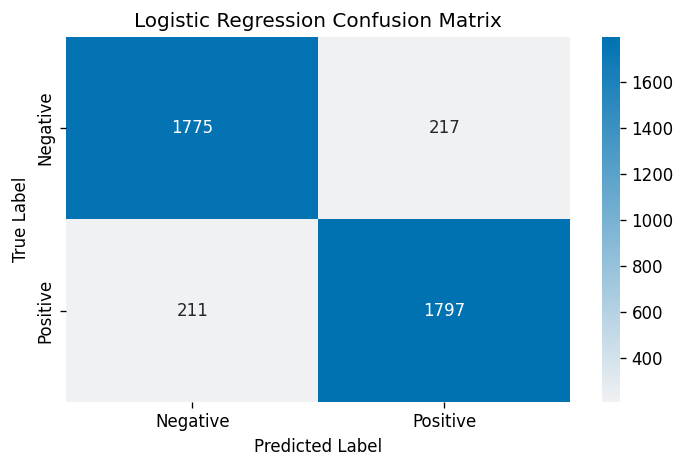

In [ ]:
baseline_cm = confusion_matrix(
    y_test,
    baseline_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(CB_BLUE, as_cmap=True),
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

#Selecting the BERT model and loading

In [ ]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer:", tokenizer.__class__.__name__)
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer: BertTokenizer
Vocabulary size: 30522


#BERT Tokenizer

In [ ]:
sample_review = X_train.iloc[0]

sample_encoding = tokenizer(
    sample_review,
    truncation=True,
    padding="max_length",
    max_length=128,
    return_tensors="pt"
)

print("Original review:")
print(sample_review[:500])

print("\nInput IDs:")
print(sample_encoding["input_ids"])

print("\nAttention Mask:")
print(sample_encoding["attention_mask"])

print("\nDecoded tokens:")
print(
    tokenizer.convert_ids_to_tokens(
        sample_encoding["input_ids"][0][:30]
    )
)

Original review:
The superb star quality of Gerard Philipe, who died way too young, leaps from the screen in this witty, funny, sly swashbuckling comedy with plenty of sword fencing and knockabout antics. Charmingly loopy in its' storytelling, impossible to resist. A sweet romantic comedy with a very young Gina Lollobrigida as the love interest. A movie one will remember with great affection.

Input IDs:
tensor([[  101,  1996, 21688,  2732,  3737,  1997, 11063,  5170,  2063,  1010,
          2040,  2351,  2126,  2205,  2402,  1010, 29195,  2013,  1996,  3898,
          1999,  2023, 25591,  1010,  6057,  1010, 18230, 25430, 11823, 24204,
          2989,  4038,  2007,  7564,  1997,  4690, 15962,  1998,  7324,  7875,
          5833, 27440,  1012, 11951,  2135,  7077,  2100,  1999,  2049,  1005,
         20957,  1010,  5263,  2000,  9507,  1012,  1037,  4086,  6298,  4038,
          2007,  1037,  2200,  2402, 17508,  8840,  7174, 23736,  5856,  2850,
          2004,  1996,  2293,  3037,  1

#Investigating the token lengths

In [ ]:
sample_for_lengths = X_train.sample(
    n=min(5000, len(X_train)),
    random_state=SEED
)

token_lengths = []

for text in sample_for_lengths:
    tokens = tokenizer(
        text,
        add_special_tokens=True,
        truncation=False
    )

    token_lengths.append(len(tokens["input_ids"]))

token_lengths = np.array(token_lengths)

print("Mean token length :", token_lengths.mean())
print("Median token length:", np.median(token_lengths))
print("95th percentile   :", np.percentile(token_lengths, 95))
print("Maximum           :", token_lengths.max())

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (699 > 512). Running this sequence through the model will result in indexing errors


Mean token length : 301.5438
Median token length: 225.0
95th percentile   : 774.0
Maximum           : 1974


In [ ]:
MAX_LENGTH = 128

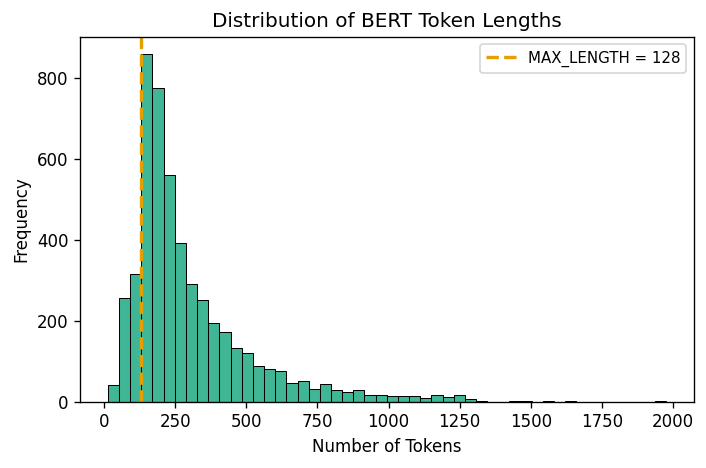

In [ ]:
plt.figure(figsize=(6, 4))

sns.histplot(
    token_lengths,
    bins=50,
    color=CB_GREEN
)

plt.axvline(
    MAX_LENGTH,
    color=CB_ORANGE,
    linestyle="--",
    linewidth=2,
    label=f"MAX_LENGTH = {MAX_LENGTH}"
)

plt.title("Distribution of BERT Token Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")

plt.legend()
plt.tight_layout()
plt.show()

#Creating the Pytorch Dataset

In [ ]:
class IMDbDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):

        text = str(self.texts[index])
        label = int(self.labels[index])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
train_dataset = IMDbDataset(
    X_train,
    y_train,
    tokenizer,
    MAX_LENGTH
)

test_dataset = IMDbDataset(
    X_test,
    y_test,
    tokenizer,
    MAX_LENGTH
)

print("Training dataset:", len(train_dataset))
print("Testing dataset :", len(test_dataset))

Training dataset: 16000
Testing dataset : 4000


In [ ]:
#Checking with one example
example = train_dataset[0]

print("Input IDs shape:", example["input_ids"].shape)
print("Attention mask shape:", example["attention_mask"].shape)
print("Label:", example["labels"])

Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: tensor(1)


In [ ]:
BATCH_SIZE = 8

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Testing batches :", len(test_loader))

Batch size: 8
Training batches: 2000
Testing batches : 500


#For sequence classification loading BERT

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model = model.to(device)

print(model.config)

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.13.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



In [ ]:
model.gradient_checkpointing_enable()

print("Gradient checkpointing enabled:",
      model.is_gradient_checkpointing)

Gradient checkpointing enabled: True


#Loading the optimizer

In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

In [ ]:
EPOCHS = 2

In [ ]:
total_training_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_training_steps),
    num_training_steps=total_training_steps
)

print("Total training steps:", total_training_steps)

Total training steps: 4000


#Training Function

In [ ]:
def train_one_epoch(model, data_loader, optimizer, scheduler, device):

    model.train()

    total_loss = 0
    predictions = []
    true_labels = []

    for batch in data_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.detach().cpu().numpy())
        true_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(data_loader)

    metrics = calculate_metrics(
        true_labels,
        predictions
    )

    return avg_loss, metrics

#Evaluation

In [ ]:
def evaluate_model(model, data_loader, device):

    model.eval()

    total_loss = 0
    predictions = []
    true_labels = []
    probabilities = []

    with torch.no_grad():

        for batch in data_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()

            predictions.extend(
                preds.cpu().numpy()
            )

            true_labels.extend(
                labels.cpu().numpy()
            )

            probabilities.extend(
                probs.cpu().numpy()
            )

    avg_loss = total_loss / len(data_loader)

    metrics = calculate_metrics(
        true_labels,
        predictions
    )

    return (
        avg_loss,
        metrics,
        np.array(predictions),
        np.array(true_labels),
        np.array(probabilities)
    )

#BERT Fine tunning

In [ ]:
history = {
    "train_loss": [],
    "test_loss": [],
    "train_accuracy": [],
    "test_accuracy": [],
    "train_f1": [],
    "test_f1": []
}

for epoch in range(EPOCHS):


    print(f"Epoch {epoch + 1}/{EPOCHS}")


    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        device
    )

    (
        test_loss,
        test_metrics,
        test_predictions,
        test_true_labels,
        test_probabilities
    ) = evaluate_model(
        model,
        test_loader,
        device
    )

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    history["train_accuracy"].append(
        train_metrics["Accuracy"]
    )

    history["test_accuracy"].append(
        test_metrics["Accuracy"]
    )

    history["train_f1"].append(
        train_metrics["F1-score"]
    )

    history["test_f1"].append(
        test_metrics["F1-score"]
    )

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Test Loss      : {test_loss:.4f}")
    print(f"Train Accuracy : {train_metrics['Accuracy']:.4f}")
    print(f"Test Accuracy  : {test_metrics['Accuracy']:.4f}")
    print(f"Train F1       : {train_metrics['F1-score']:.4f}")
    print(f"Test F1        : {test_metrics['F1-score']:.4f}")

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch 1/2
Train Loss     : 0.3926
Test Loss      : 0.3334
Train Accuracy : 0.8280
Test Accuracy  : 0.8768
Train F1       : 0.8280
Test F1        : 0.8767
Epoch 2/2
Train Loss     : 0.2418
Test Loss      : 0.4648
Train Accuracy : 0.9293
Test Accuracy  : 0.8778
Train F1       : 0.9293
Test F1        : 0.8777


#Training Progress and comparison Plots

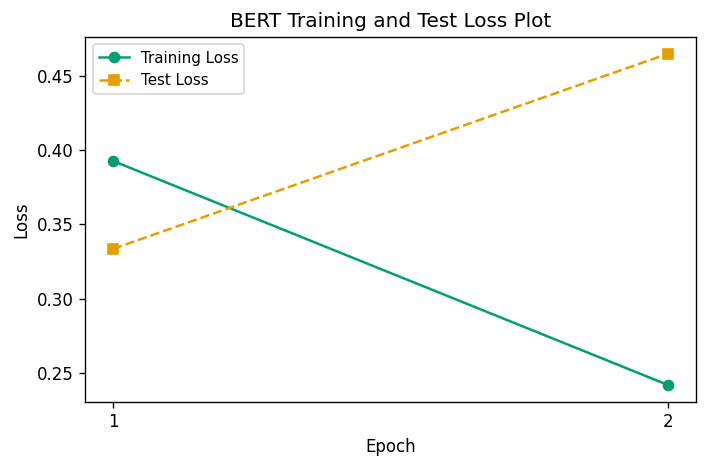

In [ ]:
plt.figure(figsize=(6, 4))

epochs_range = range(1, EPOCHS + 1)

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    color=CB_GREEN,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["test_loss"],
    marker="s",
    linestyle="--",
    color=CB_ORANGE,
    label="Test Loss"
)

plt.title("BERT Training and Test Loss Plot")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs_range)

plt.legend()
plt.tight_layout()
plt.show()

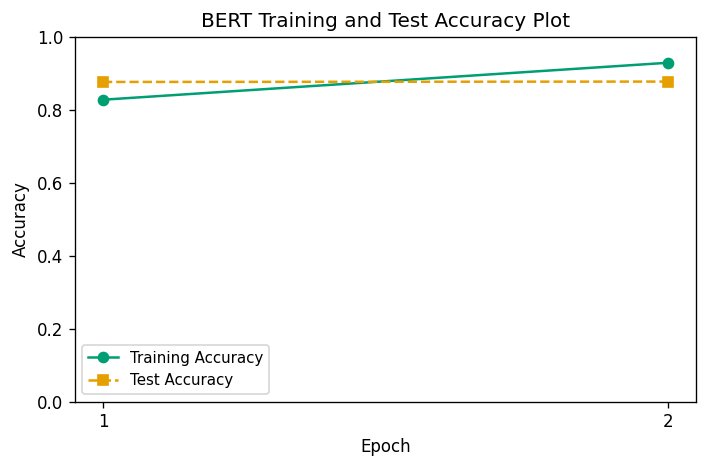

In [ ]:
plt.figure(figsize=(6, 4))
epochs_range = range(1, EPOCHS + 1)
plt.plot(
    epochs_range,
    history["train_accuracy"],
    marker="o",
    color=CB_GREEN,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["test_accuracy"],
    marker="s",
    linestyle="--",
    color=CB_ORANGE,
    label="Test Accuracy"
)

plt.title("BERT Training and Test Accuracy Plot")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs_range)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

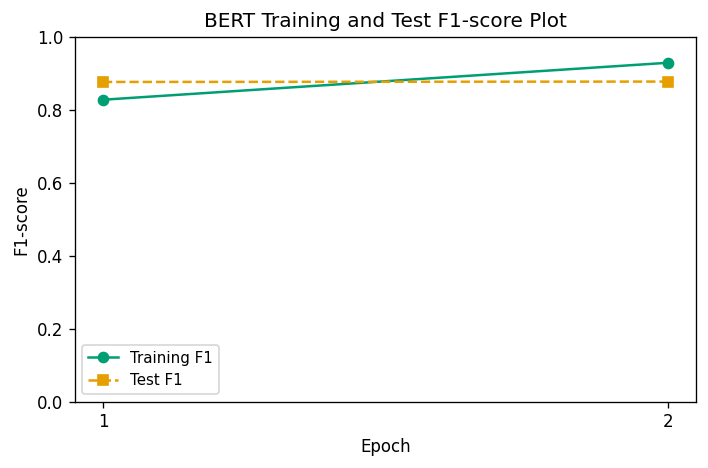

In [ ]:
plt.figure(figsize=(6, 4))
epochs_range = range(1, EPOCHS + 1)
plt.plot(
    epochs_range,
    history["train_f1"],
    marker="o",
    color=CB_GREEN,
    label="Training F1"
)

plt.plot(
    epochs_range,
    history["test_f1"],
    marker="s",
    linestyle="--",
    color=CB_ORANGE,
    label="Test F1"
)

plt.title("BERT Training and Test F1-score Plot")
plt.xlabel("Epoch")
plt.ylabel("F1-score")
plt.xticks(epochs_range)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
(
    bert_test_loss,
    bert_metrics,
    bert_predictions,
    bert_true_labels,
    bert_probabilities
) = evaluate_model(
    model,
    test_loader,
    device
)

print("BERT Final Results are as follow:")
print(f"Loss      : {bert_test_loss:.4f}")

for metric, value in bert_metrics.items():
    print(f"{metric}: {value:.4f}")

BERT Final Results are as follow:
Loss      : 0.4648
Accuracy: 0.8778
Precision: 0.8778
Recall: 0.8778
F1-score: 0.8777


In [ ]:
print(
    classification_report(
        bert_true_labels,
        bert_predictions,
        target_names=["Negative", "Positive"],
        digits=4
    )
)

              precision    recall  f1-score   support

    Negative     0.8797    0.8740    0.8769      1992
    Positive     0.8758    0.8815    0.8786      2008

    accuracy                         0.8778      4000
   macro avg     0.8778    0.8777    0.8777      4000
weighted avg     0.8778    0.8778    0.8777      4000



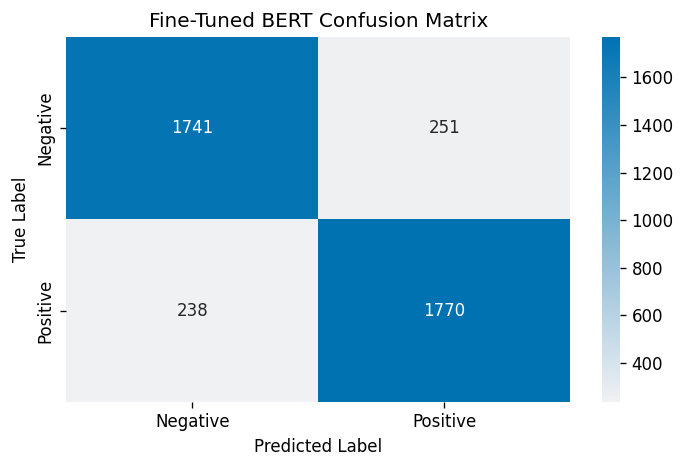

In [ ]:
bert_cm = confusion_matrix(
    bert_true_labels,
    bert_predictions
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    bert_cm,
    annot=True,
    fmt="d",
    cmap=sns.light_palette(CB_BLUE, as_cmap=True),
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Fine-Tuned BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

#Comaprison using changed matrices

In [ ]:
# Hyperparameter Experiment: using the Learning Rate
TUNING_SIZE = 4000

X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=TUNING_SIZE,
    random_state=SEED,
    stratify=y_train
)

X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune,
    y_tune,
    test_size=0.20,
    random_state=SEED,
    stratify=y_tune
)

X_tune_train = X_tune_train.reset_index(drop=True)
X_tune_val = X_tune_val.reset_index(drop=True)
y_tune_train = y_tune_train.reset_index(drop=True)
y_tune_val = y_tune_val.reset_index(drop=True)

print("Tuning training samples:", len(X_tune_train))
print("Tuning validation samples:", len(X_tune_val))

Tuning training samples: 3200
Tuning validation samples: 800


In [ ]:
tune_train_dataset = IMDbDataset(
    X_tune_train,
    y_tune_train,
    tokenizer,
    MAX_LENGTH
)

tune_val_dataset = IMDbDataset(
    X_tune_val,
    y_tune_val,
    tokenizer,
    MAX_LENGTH
)

tune_train_loader = DataLoader(
    tune_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

tune_val_loader = DataLoader(
    tune_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(tune_train_loader))
print("Validation batches:", len(tune_val_loader))

Training batches: 400
Validation batches: 100


#Comparison with different Learning Rates

In [ ]:
LEARNING_RATES = [2e-5, 3e-5]

tuning_results = []

for lr in LEARNING_RATES:


    print(f"Testing learning rate: {lr}")


    # Here Loading a fresh BERT model for each experiment
    tune_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    ).to(device)

    # Memory optimisation step
    tune_model.gradient_checkpointing_enable()

    tune_optimizer = torch.optim.AdamW(
        tune_model.parameters(),
        lr=lr,
        weight_decay=0.01
    )

    #only one epoch for this preliminary experiment
    tune_epochs = 1
    total_steps = len(tune_train_loader) * tune_epochs

    tune_scheduler = get_linear_schedule_with_warmup(
        tune_optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    train_loss, train_metrics = train_one_epoch(
        tune_model,
        tune_train_loader,
        tune_optimizer,
        tune_scheduler,
        device
    )

    (
        val_loss,
        val_metrics,
        val_predictions,
        val_true_labels,
        val_probabilities
    ) = evaluate_model(
        tune_model,
        tune_val_loader,
        device
    )

    tuning_results.append({
        "Learning Rate": lr,
        "Train Loss": train_loss,
        "Validation Loss": val_loss,
        "Validation Accuracy": val_metrics["Accuracy"],
        "Validation Precision": val_metrics["Precision"],
        "Validation Recall": val_metrics["Recall"],
        "Validation F1": val_metrics["F1-score"]
    })

    print(f"Train Loss          : {train_loss:.4f}")
    print(f"Validation Loss     : {val_loss:.4f}")
    print(f"Validation Accuracy : {val_metrics['Accuracy']:.4f}")
    print(f"Validation F1       : {val_metrics['F1-score']:.4f}")

    del tune_model
    del tune_optimizer
    del tune_scheduler

    torch.cuda.empty_cache()

Testing learning rate: 2e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train Loss          : 0.4339
Validation Loss     : 0.3565
Validation Accuracy : 0.8512
Validation F1       : 0.8512
Testing learning rate: 3e-05


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train Loss          : 0.4166
Validation Loss     : 0.3664
Validation Accuracy : 0.8500
Validation F1       : 0.8499


In [ ]:
tuning_df = pd.DataFrame(tuning_results)
tuning_display = tuning_df.copy()

tuning_display["Learning Rate"] = tuning_display[
    "Learning Rate"
].apply(lambda x: f"{x:.0e}")

display(tuning_display.round(4))

,Learning Rate,Train Loss,Validation Loss,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,2e-05,0.4339,0.3565,0.8512,0.8513,0.8512,0.8512
1,3e-05,0.4166,0.3664,0.8500,0.8505,0.8500,0.8499


In [ ]:
best_row = tuning_df.loc[
    tuning_df["Validation F1"].idxmax()
]

BEST_LR = best_row["Learning Rate"]

print(f"Best learning rate: {BEST_LR:.0e}")
print(f"Best validation F1: {best_row['Validation F1']:.4f}")

Best learning rate: 2e-05
Best validation F1: 0.8512


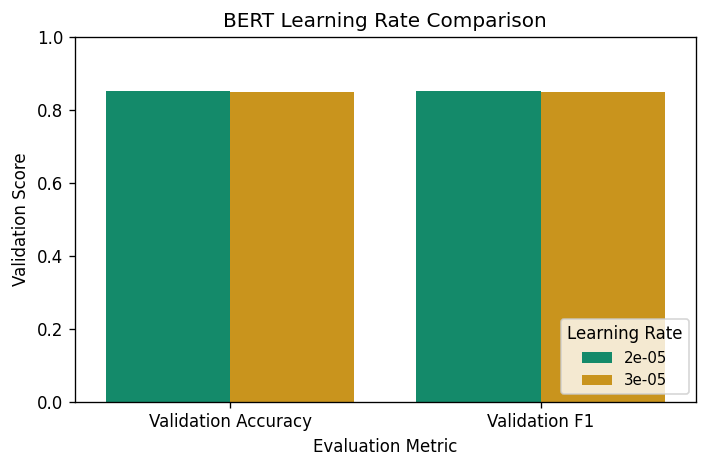

In [ ]:
lr_plot_df = tuning_df[
    ["Learning Rate", "Validation Accuracy", "Validation F1"]
].melt(
    id_vars="Learning Rate",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=lr_plot_df,
    x="Metric",
    y="Score",
    hue="Learning Rate",
    palette=[CB_GREEN, CB_ORANGE]
)

plt.title("BERT Learning Rate Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Validation Score")
plt.ylim(0, 1)

plt.legend(
    title="Learning Rate",
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "Fine-Tuned BERT"
    ],

    "Accuracy": [
        baseline_metrics["Accuracy"],
        bert_metrics["Accuracy"]
    ],

    "Precision": [
        baseline_metrics["Precision"],
        bert_metrics["Precision"]
    ],

    "Recall": [
        baseline_metrics["Recall"],
        bert_metrics["Recall"]
    ],

    "F1-score": [
        baseline_metrics["F1-score"],
        bert_metrics["F1-score"]
    ]
})

comparison_df = comparison_df.round(4)

display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.8930,0.8930,0.8930,0.8930
1,Fine-Tuned BERT,0.8778,0.8778,0.8778,0.8777


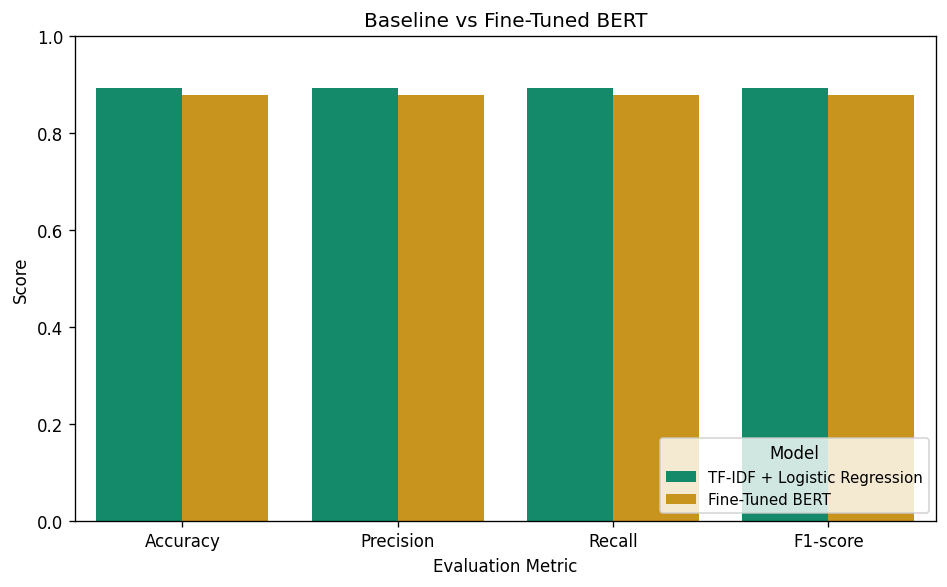

In [ ]:
comparison_long = comparison_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_long,
    x="Metric",
    y="Score",
    hue="Model",
    palette=[CB_GREEN, CB_ORANGE]
)

plt.title("Baseline vs Fine-Tuned BERT")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(
    title="Model",
    loc="lower right"
)

plt.tight_layout()
plt.show()

#Error Analysis of BERT

In [ ]:
improvement_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],

    "Baseline": [
        baseline_metrics["Accuracy"],
        baseline_metrics["Precision"],
        baseline_metrics["Recall"],
        baseline_metrics["F1-score"]
    ],

    "BERT": [
        bert_metrics["Accuracy"],
        bert_metrics["Precision"],
        bert_metrics["Recall"],
        bert_metrics["F1-score"]
    ]
})

improvement_df["Absolute Improvement"] = (
    improvement_df["BERT"] -
    improvement_df["Baseline"]
)

improvement_df["Relative Improvement (%)"] = (
    improvement_df["Absolute Improvement"] /
    improvement_df["Baseline"]
) * 100

display(improvement_df.round(4))

,Metric,Baseline,BERT,Absolute Improvement,Relative Improvement (%)
0,Accuracy,0.893,0.8778,-0.0152,-1.7077
1,Precision,0.893,0.8778,-0.0152,-1.7065
2,Recall,0.893,0.8778,-0.0152,-1.7077
3,F1-score,0.893,0.8777,-0.0153,-1.7080


In [ ]:
error_analysis = pd.DataFrame({
    "Review": X_test,
    "True_Label": y_test,
    "Predicted_Label": bert_predictions,
    "Positive_Probability": bert_probabilities[:, 1]
})

error_analysis["Correct"] = (
    error_analysis["True_Label"] ==
    error_analysis["Predicted_Label"]
)

error_analysis["True_Sentiment"] = error_analysis["True_Label"].map({
    0: "Negative",
    1: "Positive"
})

error_analysis["Predicted_Sentiment"] = error_analysis["Predicted_Label"].map({
    0: "Negative",
    1: "Positive"
})

errors = error_analysis[
    error_analysis["Correct"] == False
].copy()

print("Total BERT errors:", len(errors))

display(
    errors[
        [
            "Review",
            "True_Sentiment",
            "Predicted_Sentiment",
            "Positive_Probability"
        ]
    ].head(10)
)

Total BERT errors: 489


,Review,True_Sentiment,Predicted_Sentiment,Positive_Probability
1,This movie is a perfect adaptation of the Engl...,Negative,Positive,0.994212
7,"First of all, I would like to clarify that I c...",Negative,Positive,0.996318
13,It's interesting that someone made a compariso...,Positive,Negative,0.471986
28,Possible Spoilers As Peter Jackson has so bril...,Negative,Positive,0.689639
37,I couldn't believe that the Adult Swim guys ca...,Positive,Negative,0.128427
46,Surrender Cinema has been known for their extr...,Negative,Positive,0.945672
67,I remember this film as the other person that ...,Positive,Negative,0.001796
69,"Of course, ""Flatley"" is already not exactly th...",Negative,Positive,0.977376
75,"The 1967 In Cold Blood was perhaps more like ""...",Positive,Negative,0.049362
81,I opted to see the film at the recent Dubai Fi...,Negative,Positive,0.976025


In [ ]:
error_analysis["Confidence"] = np.where(
    error_analysis["Predicted_Label"] == 1,
    error_analysis["Positive_Probability"],
    1 - error_analysis["Positive_Probability"]
)

confident_errors = error_analysis[
    error_analysis["Correct"] == False
].sort_values(
    "Confidence",
    ascending=False
)

display(
    confident_errors[
        [
            "Review",
            "True_Sentiment",
            "Predicted_Sentiment",
            "Confidence"
        ]
    ].head(10)
)

,Review,True_Sentiment,Predicted_Sentiment,Confidence
3642,"But the opposite, sorry bud, i completely unde...",Positive,Negative,0.998595
3906,The main problem I see with this film is its s...,Positive,Negative,0.998577
819,"Okay, first of all I got this movie as a Chris...",Positive,Negative,0.998486
2628,I saw once No Man's Land (1987) - IMDB link ht...,Positive,Negative,0.998439
3804,Good for an evening's entertainment - but the ...,Positive,Negative,0.998373
154,This show was crap when it first came on. The ...,Positive,Negative,0.998372
3151,"""Distant"" is a slice-of-Turkish-life flick whi...",Positive,Negative,0.998370
1425,"Bad script, bad direction, over the top perfor...",Positive,Negative,0.998360
2829,"Its not sophisticated, and nobody in the credi...",Positive,Negative,0.998346
3694,Ernest Borgnine was so wasted in this movie.Th...,Positive,Negative,0.998314


#Testing the model

In [ ]:
def predict_sentiment(text):

    cleaned_text = clean_text(text)

    encoding = tokenizer(
        cleaned_text,
        add_special_tokens=True,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        prediction = torch.argmax(
            probabilities,
            dim=1
        ).item()

    sentiment = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    confidence = probabilities[0][prediction].item()

    return sentiment, confidence

In [ ]:
reviews = [
    "This movie was absolutely fantastic. I loved every minute of it.",
    "The film was boring, predictable and a complete waste of time."
]

for review in reviews:

    sentiment, confidence = predict_sentiment(review)

    print("Review:", review)
    print("Prediction:", sentiment)
    print(f"Confidence: {confidence:.4f}")

Review: This movie was absolutely fantastic. I loved every minute of it.
Prediction: Positive
Confidence: 0.9975
Review: The film was boring, predictable and a complete waste of time.
Prediction: Negative
Confidence: 0.9989


#Saving the model

In [ ]:
SAVE_PATH = "/content/imdb_bert_sentiment"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print("Model saved to:", SAVE_PATH)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/imdb_bert_sentiment


In [ ]:
final_results = comparison_df.copy()

print("FINAL MODEL COMPARISON")


display(final_results)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-score
0,TF-IDF + Logistic Regression,0.8930,0.8930,0.8930,0.8930
1,Fine-Tuned BERT,0.8778,0.8778,0.8778,0.8777
